### The idea behind this notebook:
Let a NN learn the u (displacement) field directly, rather than learning F.

In [33]:
import os
n_cores = 4
os.environ["XLA_FLAGS"] = '--xla_force_host_platform_device_count={}'.format(n_cores)

from jax import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import numpy as np
import pickle
from jax import jit, vmap, grad, jacrev
from jax.lax import cond, scan
import jax.random as random
key = random.PRNGKey(2022)
import jax.example_libraries.optimizers as optimizers
from jax.flatten_util import ravel_pytree
from jax.sharding import PositionalSharding
from functools import partial

import matplotlib.pyplot as plt
import pandas as pd

from utils import train, coords_2_strain_nn, nn_fpass
from utils import train_colloc_parallel as train_colloc, init_params_nn, ff_nn, divergence, bd_forces, a1, a2, lr
from utils_hyperelasticity import NODE, init_layers, NODE_model_iso, init_params_iso, GOH_model, eval_Cauchy, eval_Cauchy_vmap, eval_P, eval_P_vmap
from utils_hyperelasticity import ThreeDElasticity, merge_c_s_params_iso, split_c_s_params_iso
from fem import plotmesh, fe_solver_2D, vahid_anisohyper_inv, apply_bc_biax

from jax_fem.core import FEM
from jax_fem.solver import solver
from jax_fem.utils import save_sol
from jax_fem.generate_mesh import box_mesh, get_meshio_cell_type, Mesh, rectangle_mesh

from PIL import Image, ImageFilter
from jaxinterp2d import interp2d

E_fun = vmap(lambda F: 0.5*(F.T@F - jnp.eye(2)))


with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/stiff2_hetero.npy', 'rb') as f:
    _,_,_,_,P_xx_gt,P_yy_gt = pickle.load(f)
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/stiff2_hetero_disp.npy', 'rb') as f:
    x,y,ux_hist,uy_hist = pickle.load(f)
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/temp.npy', 'rb') as f:
    E_hist_dic = pickle.load(f)

x1 = 4
x2 = 42
y1 = 2
y2 = 40
out = []
for aux in E_hist_dic:
    out.append(aux.transpose([2,0,1]).reshape([42,43,2,2]).transpose([1,0,2,3])[x1:x2,y1:y2,:,:].reshape([-1,2,2])) # I know. wtf?
E_hist_dic = np.array(out)
elem_X = np.stack([x.flatten(),y.flatten()]).T


# we don't need to use all of that data
i1 = 10
i2 = None
skip = 30
P_xx_gt = jnp.array(P_xx_gt[i1:i2:skip])
P_yy_gt = jnp.array(P_yy_gt[i1:i2:skip])
ux_hist = jnp.array(ux_hist[i1:i2:skip])
uy_hist = jnp.array(uy_hist[i1:i2:skip])

E_hist_dic = E_hist_dic[i1:i2:skip]




def coords_2_disp_x(X,Y,t,params):
    inp = jnp.stack([X,Y,t])[None,:]
    out = coords_2_strain_nn(inp, params)
    t = t.astype(int)
    return out[0,0]*disps_x_stdv[t] + disps_x_mean[t]
def coords_2_disp_y(X,Y,t,params):
    inp = jnp.stack([X,Y,t])[None,:]
    out = coords_2_strain_nn(inp, params)
    t = t.astype(int)
    return out[0,1]*disps_y_stdv[t] + disps_y_mean[t]

def F_xx_fn(inp,params):
    return grad(coords_2_disp_x           )(inp[0], inp[1], inp[2], params) + 1.0
def F_yy_fn(inp,params):
    return grad(coords_2_disp_y, argnums=1)(inp[0], inp[1], inp[2], params) + 1.0
def F_yx_fn(inp,params):
    return grad(coords_2_disp_y           )(inp[0], inp[1], inp[2], params)
def F_xy_fn(inp,params):
    return grad(coords_2_disp_x, argnums=1)(inp[0], inp[1], inp[2], params)

coords_2_strain_nn2 = vmap(lambda inp, params: jnp.stack([F_xx_fn(inp, params), F_xy_fn(inp, params), F_yx_fn(inp, params), F_yy_fn(inp,params)]), in_axes=(0, None))






# These are modified versions of the same code from utils.py. The only difference is that I use coords_2_strain_nn2 in get_P.
def get_P(X, Y, t, Lambda_params, coord_2_strain_params, model):
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn2(jnp.array([X,Y,t])[None,:], coord_2_strain_params).flatten()
    # get NODE individual-specific params, phi, from the Lambda NN
    Lambda_inp = jnp.array([X,Y]).reshape([-1,2])
    phi = ff_nn(Lambda_inp, Lambda_params).flatten()
    # Make predictions with this NODE
    ugrad = jnp.array([[F_xx-1.0, F_xy],[F_yx, F_yy-1.0]])
    P = ThreeDElasticity(model).ugrad_2_P(ugrad, phi, 2)
    return P[0,0], P[1,0], P[0,1], P[1,1]
get_P_vmap = vmap(get_P, in_axes=(0,0,0,None,None,None), out_axes=(0,0,0,0))

get_Pxx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[0]
get_Pyx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[1]
get_Pxy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[2]
get_Pyy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[3]

Grad_Pxx_X = vmap(grad(get_Pxx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0) # should return dsgm_xx/dx
Grad_Pyx_X = vmap(grad(get_Pyx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pxy_Y = vmap(grad(get_Pyx, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pyy_Y = vmap(grad(get_Pyy, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)

@partial(jit, static_argnums=(4,))
def bd_forces(Lambda_params, t, bd_X, c2s_params, model):
    rgt_bd_X, top_bd_X, lft_bd_X, bot_bd_X = bd_X
    rgt_bd_P = get_P_vmap(rgt_bd_X[:,0], rgt_bd_X[:,1], t*jnp.ones_like(rgt_bd_X[:,0]), Lambda_params, c2s_params, model)
    top_bd_P = get_P_vmap(top_bd_X[:,0], top_bd_X[:,1], t*jnp.ones_like(top_bd_X[:,0]), Lambda_params, c2s_params, model)
    lft_bd_P = get_P_vmap(lft_bd_X[:,0], lft_bd_X[:,1], t*jnp.ones_like(lft_bd_X[:,0]), Lambda_params, c2s_params, model)
    bot_bd_P = get_P_vmap(bot_bd_X[:,0], bot_bd_X[:,1], t*jnp.ones_like(bot_bd_X[:,0]), Lambda_params, c2s_params, model)

    rgt_bd_frc = jnp.sum(rgt_bd_P[0]*1.0) # Assume area of edge = 1.0
    top_bd_frc = jnp.sum(top_bd_P[3]*1.0)
    lft_bd_frc = jnp.sum(lft_bd_P[0]*1.0)
    bot_bd_frc = jnp.sum(bot_bd_P[3]*1.0)
    return rgt_bd_frc, top_bd_frc, lft_bd_frc, bot_bd_frc

@partial(jit, static_argnums=(3,))
def divergence(Lambda_params, XYt, c2s_params, model):
    dPxx_dX = Grad_Pxx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPxy_dY = Grad_Pxy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyx_dX = Grad_Pyx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyy_dY = Grad_Pyy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    
    Div_X = jnp.mean(dPxx_dX + dPxy_dY)
    Div_Y = jnp.mean(dPyx_dX + dPyy_dY)
    return Div_X, Div_Y

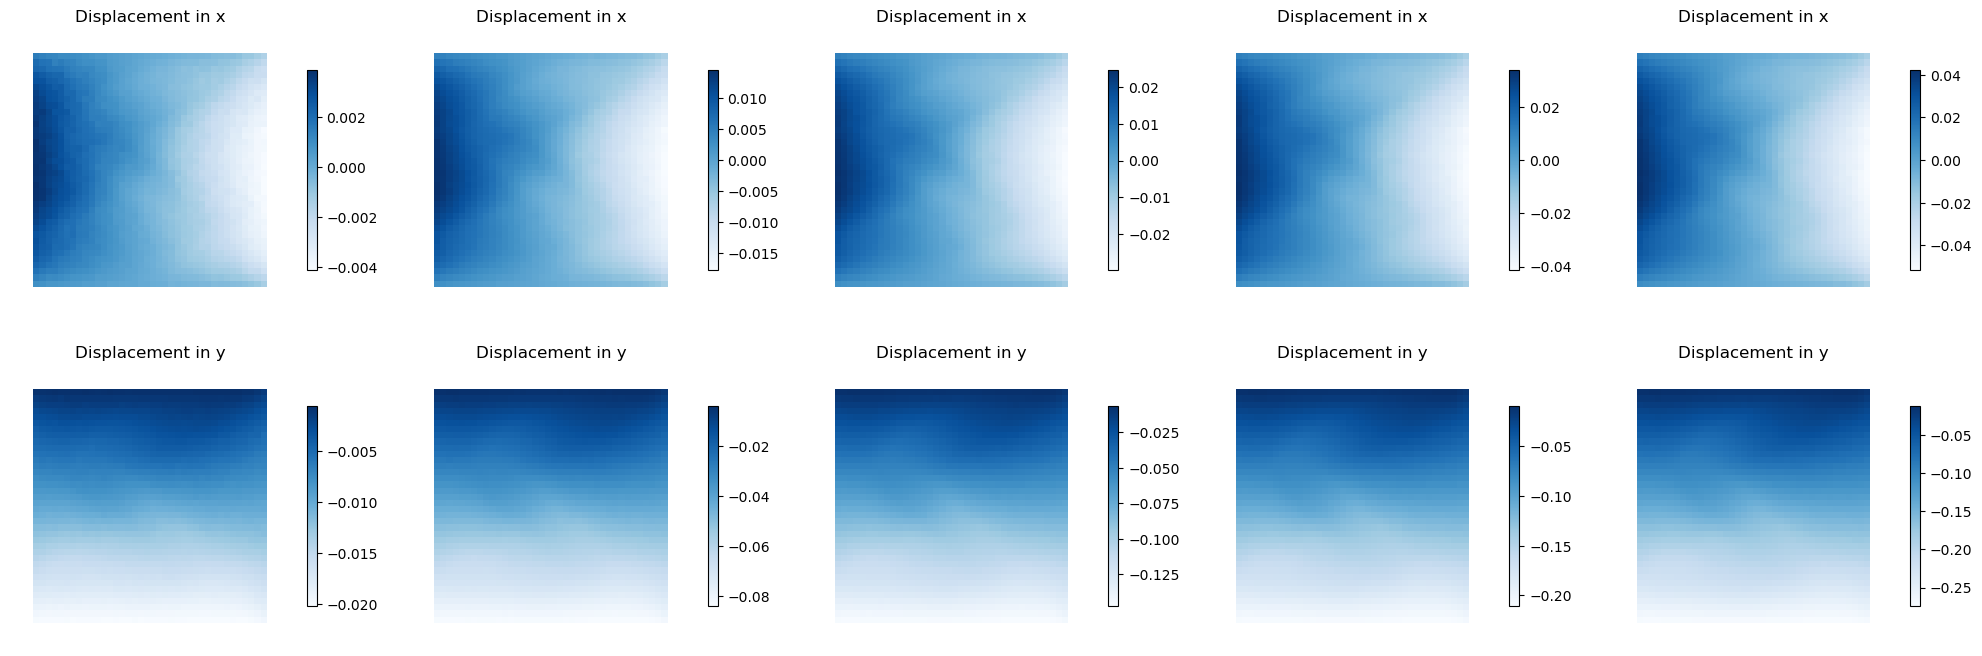

In [34]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)

Nx, Ny = x.shape[0], x.shape[1]
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])

disps_norm = []
n_panels = 5
fig, axes = plt.subplots(2,n_panels,figsize=(5*n_panels,8))
t_hist = np.arange(len(ux_hist))
disps_x_mean = []
disps_x_stdv = []
disps_y_mean = []
disps_y_stdv = []
for i in range(len(ux_hist)):
    t = t_hist[i]
    plotmesh(mesh.cells, mesh.points, ux_hist[i].flatten(), title='Displacement in x', ax=axes[0,i], ec='None'); 
    plotmesh(mesh.cells, mesh.points, uy_hist[i].flatten(), title='Displacement in y', ax=axes[1,i], ec='None'); 

    temp1 = ux_hist[i].flatten()
    temp2 = uy_hist[i].flatten()
    disps_x_mean.append(temp1.mean())
    disps_x_stdv.append(temp1.std())
    disps_y_mean.append(temp2.mean())
    disps_y_stdv.append(temp2.std())

    temp1 = (temp1 - temp1.mean())/temp1.std()
    temp2 = (temp2 - temp2.mean())/temp2.std()

    disps_norm.append(np.array([t*np.ones(len(temp1)), temp1, temp2]))
disps_norm = np.hstack(disps_norm)
disps_x_mean = jnp.hstack(disps_x_mean)
disps_x_stdv = jnp.hstack(disps_x_stdv)
disps_y_mean = jnp.hstack(disps_y_mean)
disps_y_stdv = jnp.hstack(disps_y_stdv)

### Coords_2_displacement NN

In [35]:
def loss_coords_2_disp(nn_params, X, key):
    inp, out_gt = X[:,:3], X[:,3:] # X consists of 5 columns: X, Y, lmb (time), ux, uy. The first 3 are inputs of the NN and the last 2 the outputs.
    out_pr = coords_2_strain_nn(inp, [ff_params, nn_params])
    return jnp.sum((out_pr-out_gt)**2)

n_ff = 20 # 10 cosines and 10 sines in the fourier features
n_inp = 2 # x, y
ff_params = np.random.normal(size=n_inp*n_ff).reshape([n_inp,n_ff])*0.5

nn_layers = [2*n_ff+1,40,20,10,2] # +1 because t is not fed into the fourier features part
nn_params = init_params_nn(nn_layers, key)

# lr = optimizers.exponential_decay(8e-4, 10000, 0.9)
lr = optimizers.exponential_decay(1e-3, 10000, 0.9)
# lr = 5e-4
opt_init, opt_update, get_params = optimizers.adam(lr)
opt_state = opt_init(nn_params)

X = np.vstack([elem_X]*len(ux_hist))
inp = np.hstack([X, disps_norm.T])
nn_params, train_loss, _ = train(loss_coords_2_disp, inp, get_params, opt_update, opt_state, key, nIter = 100000, print_freq=1000)
coord_2_strain_params = [ff_params, nn_params]

it 1000, train loss = 1.614959e+01
it 2000, train loss = 8.437036e+00
it 3000, train loss = 6.086761e+00
it 4000, train loss = 4.933449e+00
it 5000, train loss = 4.298615e+00
it 6000, train loss = 3.887480e+00
it 7000, train loss = 3.621072e+00
it 8000, train loss = 3.432213e+00
it 9000, train loss = 3.282072e+00
it 10000, train loss = 3.203243e+00
it 11000, train loss = 3.047558e+00
it 12000, train loss = 2.955258e+00
it 13000, train loss = 2.885993e+00
it 14000, train loss = 2.984112e+00
it 15000, train loss = 2.799669e+00
it 16000, train loss = 2.735123e+00
it 17000, train loss = 2.721846e+00
it 18000, train loss = 2.691990e+00
it 19000, train loss = 2.654015e+00
it 20000, train loss = 2.821154e+00
it 21000, train loss = 2.598745e+00
it 22000, train loss = 2.580729e+00
it 23000, train loss = 2.563909e+00
it 24000, train loss = 2.583713e+00
it 25000, train loss = 2.535880e+00
it 26000, train loss = 2.522895e+00
it 27000, train loss = 2.704324e+00
it 28000, train loss = 2.556025e+00
i

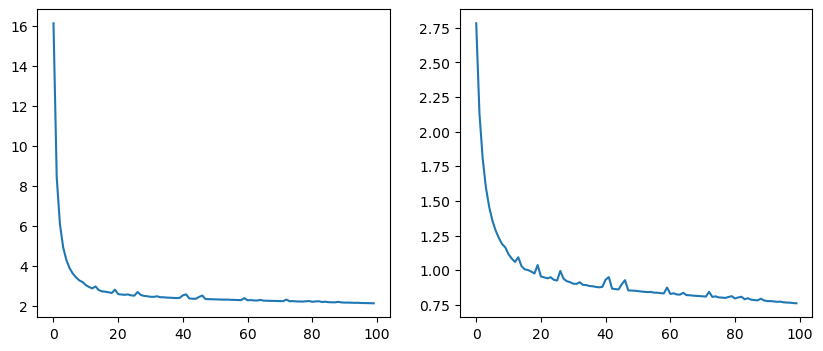

In [37]:
fig, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(train_loss)
ax[1].plot(np.log(train_loss))

### Coords_2_strain NN

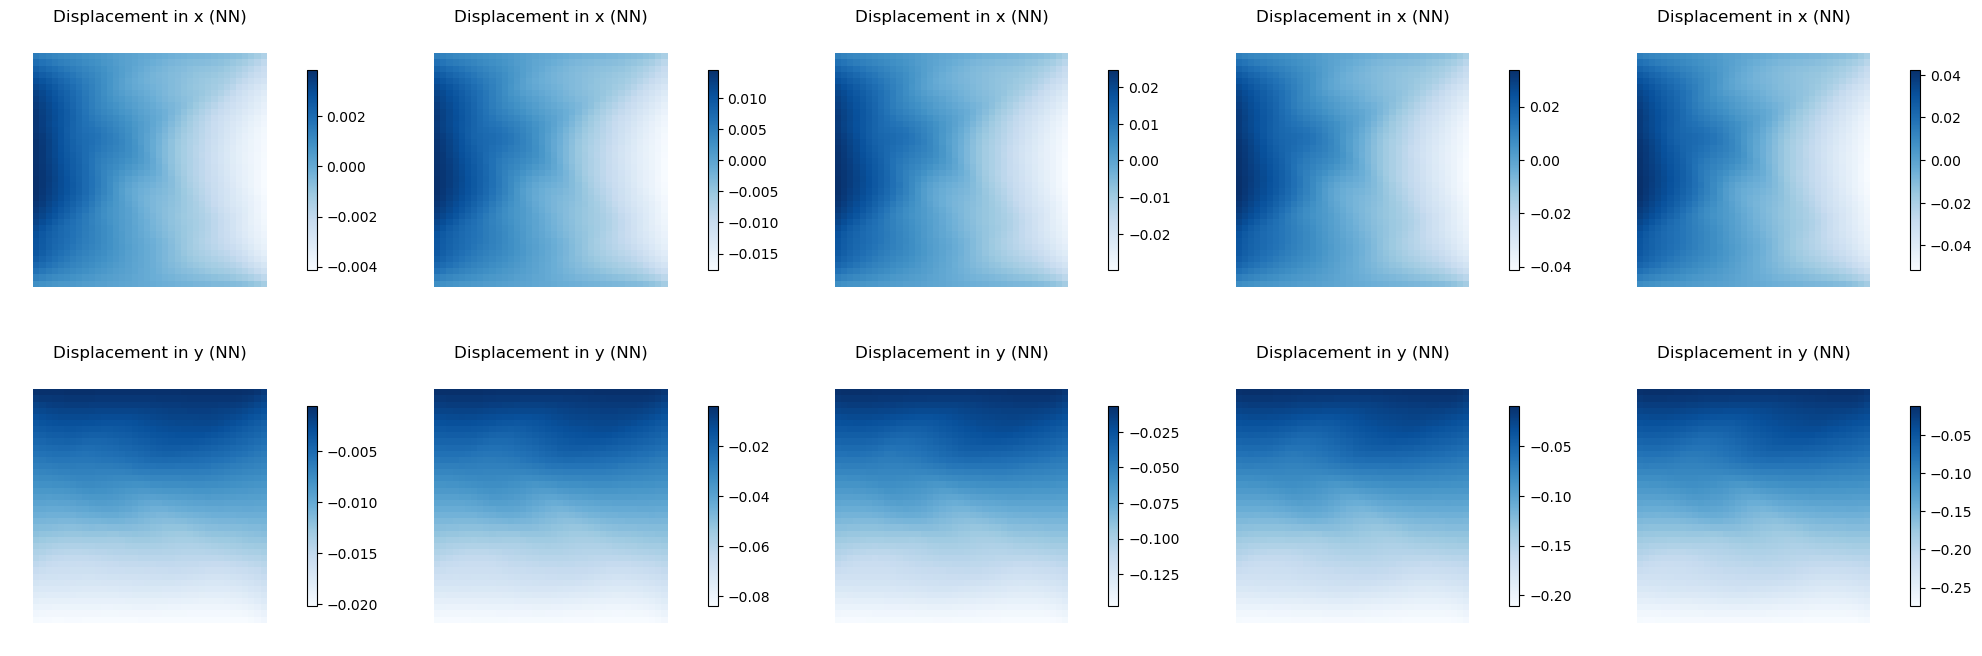

In [38]:
fig, axes = plt.subplots(2,5,figsize=(25,8))
for t in t_hist:
    disp_x = vmap(coords_2_disp_x, in_axes=(0,0,0,None))(elem_X[:,0], elem_X[:,1], t*np.ones_like(elem_X[:,0]), coord_2_strain_params)
    disp_y = vmap(coords_2_disp_y, in_axes=(0,0,0,None))(elem_X[:,0], elem_X[:,1], t*np.ones_like(elem_X[:,0]), coord_2_strain_params)
    
    plotmesh(mesh.cells, mesh.points, disp_x, title='Displacement in x (NN)', ax=axes[0, t], ec='None'); 
    plotmesh(mesh.cells, mesh.points, disp_y, title='Displacement in y (NN)', ax=axes[1, t], ec='None'); 

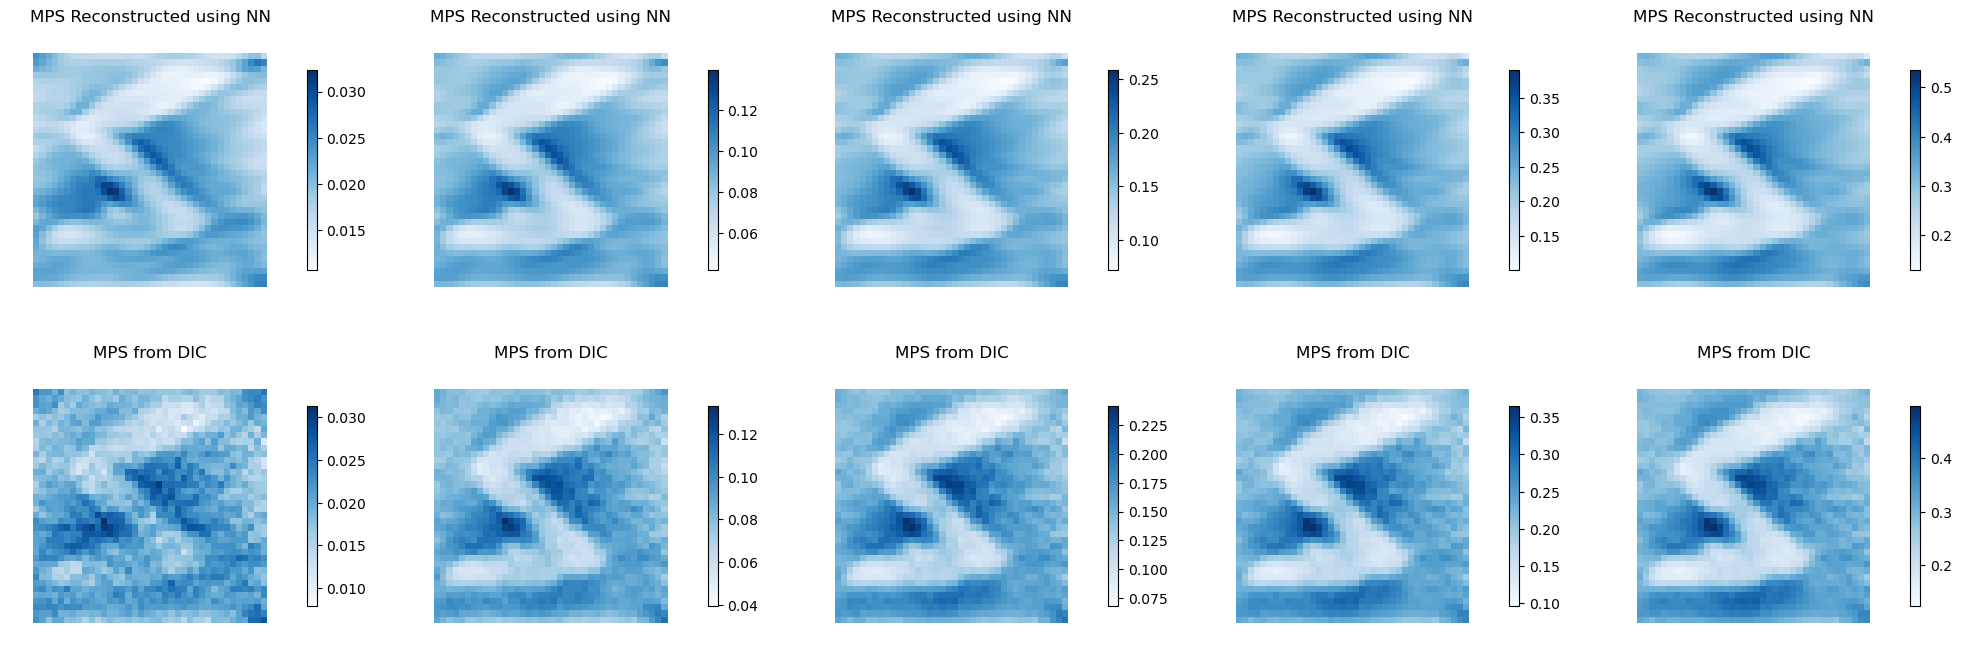

In [39]:
F_mean = []
fig, axes = plt.subplots(2,5,figsize=(25,8))
for t in t_hist:
    inp = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn2(inp, coord_2_strain_params).T

    F = np.stack([F_xx, F_xy, F_yx, F_yy]).T.reshape([-1,2,2])
    F_mean.append(F)
    
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T
    mps = np.maximum(E_11, E_22)

    if t < 5:
        plotmesh(mesh.cells, mesh.points, mps, title='MPS Reconstructed using NN', ax=axes[0][t], ec='None'); 



    # ground truth
    E = E_hist_dic[t]
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T
    mps = np.maximum(E_11, E_22)

    if t < 5:
        plotmesh(mesh.cells, mesh.points, mps, title='MPS from DIC', ax=axes[1][t], ec='None'); 
F_mean = np.array(F_mean).mean(axis=1)
F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean = F_mean[:,0,0], F_mean[:,1,1], F_mean[:,0,1], F_mean[:,1,0]

In [40]:
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/Experimental_Vahid.npy', 'wb') as f:
    pickle.dump([coord_2_strain_params,t_hist, F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean], f)

In [21]:
# identify the boundaries
rgt_bd_elems = []
top_bd_elems = []
lft_bd_elems = []
bot_bd_elems = []
for i, e in enumerate(mesh.cells):
    if any([mesh.points[e[i],0]>0.99 for i in range(4)]):
        rgt_bd_elems.append(i)
    if any([mesh.points[e[i],1]>0.99 for i in range(4)]):
        top_bd_elems.append(i)
    if any([mesh.points[e[i],0]<0.01 for i in range(4)]):
        lft_bd_elems.append(i)
    if any([mesh.points[e[i],1]<0.01 for i in range(4)]):
        bot_bd_elems.append(i)

# get the center points of the elements
rgt_bd_X = elem_X[rgt_bd_elems]
top_bd_X = elem_X[top_bd_elems]
lft_bd_X = elem_X[lft_bd_elems]
bot_bd_X = elem_X[bot_bd_elems]
bd_X = rgt_bd_X, top_bd_X, lft_bd_X, bot_bd_X

In [22]:
def loss_stress(Lambda_params, X, key): # X consists of 5 columns: X, Y, lmb (time), ux, uy.
    t = X[2:3].astype(int)
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn2(X[:3][None,:], coord_2_strain_params).T
    phi = ff_nn(X[:2][None,:], Lambda_params)
    node_params = merge_c_s_params_iso(common_params, unravel(phi.flatten()))
    
    model = NODE_model_iso(node_params)
    P = eval_P_vmap(F_xx, F_xy, F_yx, F_yy, model)
    P_xx_pr, P_yy_pr = P[:,0,0], P[:,1,1]
    return np.mean((P_xx_pr - P_xx_gt[t])**2 + (P_yy_pr-P_yy_gt[t])**2)
loss_stress_vmap = lambda a, b, c: np.mean(vmap(loss_stress, in_axes=(None,0,None))(a, b, c))

key = random.PRNGKey(0)
n_neurons = 4
common_layers = [1, n_neurons, n_neurons]
sample_layers = [n_neurons,1]
node_params = init_params_iso(common_layers, sample_layers, key)
common_params, sample_params = split_c_s_params_iso(node_params)
phi, unravel = ravel_pytree(sample_params)
n_phi = len(phi)


n_ff = 100
ff_params = np.random.normal(size=2*n_ff).reshape([2,n_ff])
nn_layers = [2*n_ff,100,50,50,n_phi]
nn_params = init_params_nn(nn_layers, key)
Lambda_params = [ff_params, nn_params]
opt_init, opt_update, get_params = optimizers.adam(5.e-4) #Original: 1.e-4
opt_state = opt_init(Lambda_params)

Lambda_params, train_loss, _ = train(loss_stress_vmap, inp, get_params, opt_update, opt_state, key, nIter = 10000, print_freq=1000, batch_size=1000)

it 1000, train loss = 3.235151e-01
it 2000, train loss = 3.227327e-01
it 3000, train loss = 3.110346e-01
it 4000, train loss = 3.160978e-01
it 5000, train loss = 3.218555e-01
it 6000, train loss = 2.978644e-01
it 7000, train loss = 3.104309e-01
it 8000, train loss = 3.041381e-01
it 9000, train loss = 3.133330e-01
it 10000, train loss = 3.104514e-01


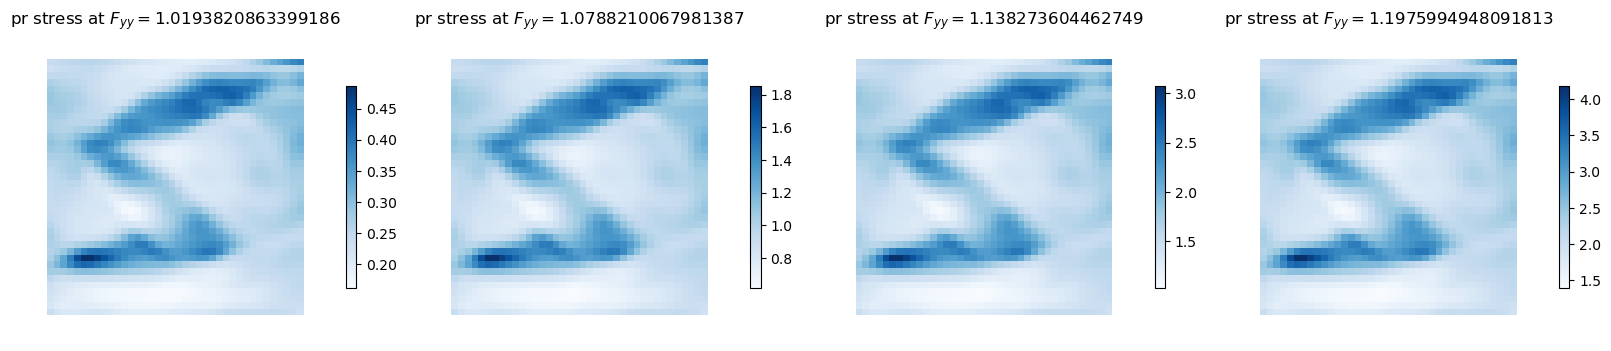

In [23]:
NODE_w_unravel = lambda params: NODE_model_iso(merge_c_s_params_iso(common_params, unravel(params)))

# Stiffness across the domain
fig, axes = plt.subplots(1,4,figsize=(20,4))

for F_xx, F_yy, F_xy, F_yx, ax in zip(F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean, axes.T):
    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)
    params_pr = ff_nn(elem_X, Lambda_params)

    c_elem_pr = []
    for params_pr_i in params_pr:
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[1,1])
    plotmesh(mesh.cells, mesh.points, c_elem_pr, title='pr stress at $F_{yy}=$' + str(F_yy), ax=ax, ec='None'); 

In [24]:
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/AM_stiff2_pre1.npy', 'wb') as f:
    pickle.dump([coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, P_xx_gt, P_yy_gt,
                 bd_X, t_hist, disps_x_mean, disps_x_stdv, disps_y_mean, disps_y_stdv, Nx, Ny], f)

## 2. Retrain

In [25]:
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/AM_stiff2_pre1.npy', 'rb') as f:
    coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, P_xx_gt, P_yy_gt, \
                 bd_X, t_hist, disps_x_mean, disps_x_stdv, disps_y_mean, disps_y_stdv, Nx, Ny = pickle.load(f)

common_params, sample_params = split_c_s_params_iso(node_params)
_, unravel = ravel_pytree(sample_params)
NODE_w_unravel = lambda params: NODE_model_iso(merge_c_s_params_iso(common_params, unravel(params)))

In [26]:
# Train
a1 = 1.0
a2 = 1.0
@jit
def loss(Lambda_params, XYt_colloc):
    Div_x, Div_y = divergence(Lambda_params, XYt_colloc, coord_2_strain_params, NODE_w_unravel)
    loss_Div = a1*(Div_x**2 + Div_y**2)

    def bd_forces_loss(_, t):
        F_rgt, F_top, F_lft, F_bot = bd_forces(Lambda_params, t, bd_X, coord_2_strain_params, NODE_w_unravel)
        P_rgt, P_top, P_lft, P_bot = F_rgt/Ny, F_top/Nx, F_lft/Ny, F_bot/Nx
        Px = P_xx_gt[jnp.array(t, int)]
        Py = P_yy_gt[jnp.array(t, int)]
        return None, a2*((P_rgt-Px)**2 + (P_top-Py)**2 + (P_lft-Px)**2 + (P_bot-Py)**2)
    loss_F = jnp.mean(scan(bd_forces_loss, init=None, xs=t_hist)[1])
    # loss_F = 0.0
    
    return loss_Div + loss_F

# lr = 1e-4
lr = optimizers.exponential_decay(1e-5, 5000, 0.9)
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

node_X_ext = jnp.hstack([mesh.points, t_hist[-1]*np.ones_like(mesh.points[:,:1])])
metric1 = lambda params, X:  bd_forces(params, t_hist[-1], bd_X, coord_2_strain_params, NODE_w_unravel)
metric2 = lambda params, X: divergence(params, node_X_ext, coord_2_strain_params, NODE_w_unravel)

Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 20000, print_freq=1000, batch_size=1000)

with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/AM_stiff2_post_Vahid.npy', 'wb') as f:
    pickle.dump([mesh, elem_X, P_xx_gt, P_yy_gt, node_params, Lambda_params, val_loss, metrics, t_hist, F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean], f)

it 1, val loss = 2.608003e-01
it 1001, val loss = 1.099121e-01
it 2001, val loss = 7.927488e-02
it 3001, val loss = 7.070773e-02
it 4001, val loss = 6.326427e-02
it 5001, val loss = 6.035577e-02
it 6001, val loss = 5.558805e-02
it 7001, val loss = 5.027319e-02
it 8001, val loss = 5.511061e-02
it 9001, val loss = 4.220519e-02
it 10001, val loss = 4.294517e-02
it 11001, val loss = 4.865231e-02
it 12001, val loss = 4.953946e-02
it 13001, val loss = 5.088636e-02
it 14001, val loss = 4.082046e-02
it 15001, val loss = 4.556503e-02
it 16001, val loss = 4.848935e-02
it 17001, val loss = 4.298980e-02
it 18001, val loss = 4.442200e-02
it 19001, val loss = 3.816757e-02


In [27]:
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/AM_stiff2_post_Vahid.npy', 'wb') as f:
    pickle.dump([mesh, elem_X, P_xx_gt, P_yy_gt, node_params, Lambda_params, val_loss, metrics, t_hist, F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean], f)

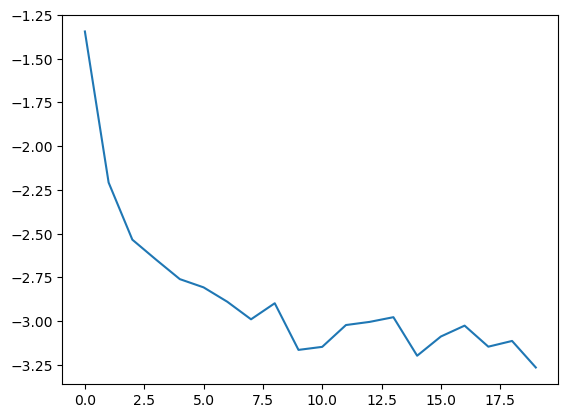

In [28]:
plt.plot(np.log(val_loss))

## 3. Test

In [29]:
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/AM_stiff2_post.npy', 'rb') as f:
    mesh, elem_X, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean = pickle.load(f)
common_params, sample_params = split_c_s_params_iso(node_params)
_, unravel = ravel_pytree(sample_params)
NODE_w_unravel = lambda params: NODE_model_iso(merge_c_s_params_iso(common_params, unravel(params)))

In [30]:
cell_type = get_meshio_cell_type('QUAD4')
Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh2 = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
elem_X = mesh2.points[mesh2.cells].mean(axis=1)

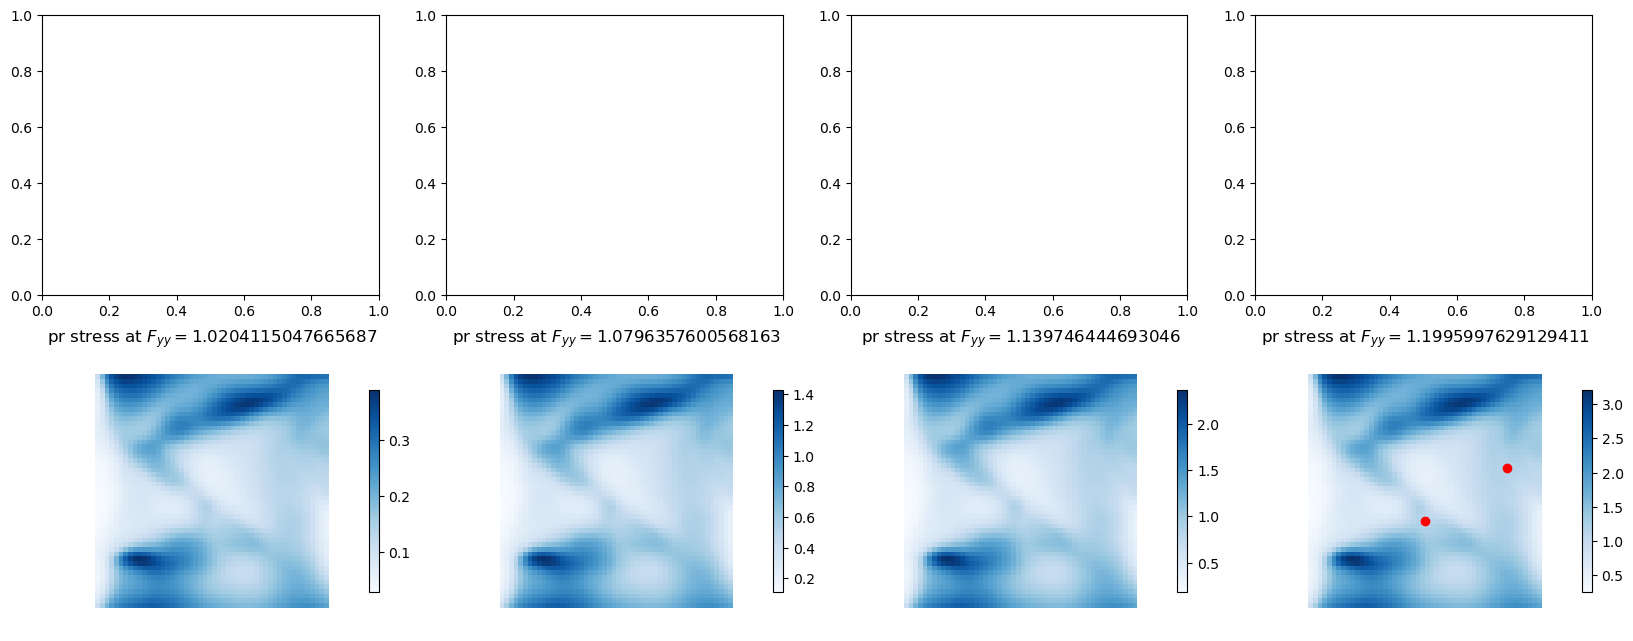

In [31]:
# Stiffness across the domain
fig, axes = plt.subplots(2,4,figsize=(20,8))
lmb_hist = [1.01929, 1.02728, 1.03531, 1.0433 , 1.05132]

extents = [[0.018, 0.021],
           [0.07, 0.08],
           [0.115, 0.13],
           [0.155, 0.17]]
for F_xx, F_yy, F_xy, F_yx, ax, extent in zip(F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean, axes.T, extents):
    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)

    params_pr = ff_nn(elem_X, Lambda_params)

    c_elem_pr = []
    for params_pr_i in params_pr:
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[1,1])
    plotmesh(mesh2.cells, mesh2.points, c_elem_pr, title='pr stress at $F_{yy}=$' + str(F_yy), ax=ax[1], ec='None'); 


p1 = np.array([[0.50, 0.37]])
p2 = np.array([[0.85, 0.60]])
axes[1,3].plot(p1[:,0], p1[:,1], 'ro')
axes[1,3].plot(p2[:,0], p2[:,1], 'ro')

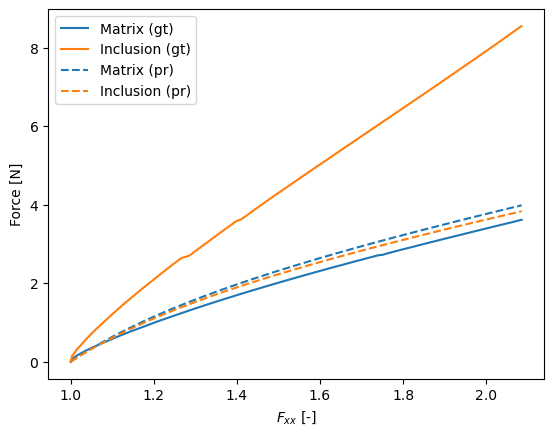

In [32]:
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/soft_homo.npy', 'rb') as f:
    x,y,F_hist_mtrx,_,force_mtrx = pickle.load(f)
F_hist_mtrx = F_hist_mtrx.mean(axis=1)

with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/stiff2_homo.npy', 'rb') as f:
    x,y,F_hist_incl,_,force_incl = pickle.load(f)
F_hist_incl = F_hist_incl.mean(axis=1)

fig, ax = plt.subplots()
ax.plot(F_hist_mtrx[:,1,1], force_mtrx, label='Matrix (gt)')
ax.plot(F_hist_incl[:,1,1], force_incl, label='Inclusion (gt)')
ax.set(xlabel='$F_{xx}$ [-]', ylabel='Force [N]')
ax.legend(); 


p1_data = []
p2_data = []
# for F_xx, F_xy, F_yx, F_yy in zip(F_xx_mean, F_xy_mean, F_yx_mean, F_yy_mean):
for F in F_hist_mtrx:
    F_xx, F_xy, F_yx, F_yy = F[0,0], F[0,1], F[1,0], F[1,1]
    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)

    params_p1 = ff_nn(p1, Lambda_params)[0]
    p1_data.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_p1, 2)[1,1])

    params_p2 = ff_nn(p2, Lambda_params)[0]
    p2_data.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_p2, 2)[1,1])


fig.gca().set_prop_cycle(None)
ax.plot(F_hist_mtrx[:,1,1], p2_data, '--', label='Matrix (pr)')
ax.plot(F_hist_mtrx[:,1,1], p1_data, '--', label='Inclusion (pr)')
ax.legend()

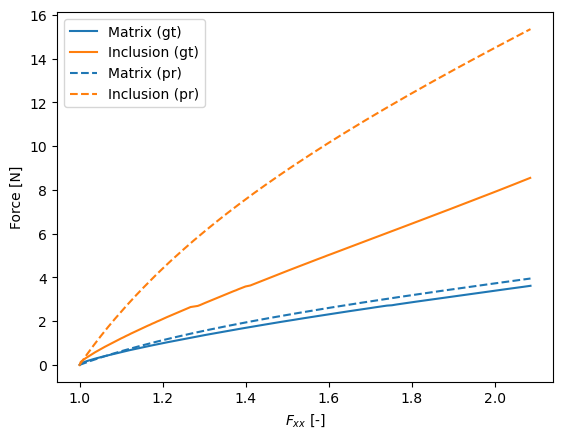

In [20]:
with open('data/manu/soft_homo.npy', 'rb') as f:
    x,y,F_hist_mtrx,_,force_mtrx = pickle.load(f)
F_hist_mtrx = F_hist_mtrx.mean(axis=1)

with open('data/manu/stiff2_homo.npy', 'rb') as f:
    x,y,F_hist_incl,_,force_incl = pickle.load(f)
F_hist_incl = F_hist_incl.mean(axis=1)

fig, ax = plt.subplots()
ax.plot(F_hist_mtrx[:,1,1], force_mtrx, label='Matrix (gt)')
ax.plot(F_hist_incl[:,1,1], force_incl, label='Inclusion (gt)')
ax.set(xlabel='$F_{xx}$ [-]', ylabel='Force [N]')
ax.legend(); 


p1_data = []
p2_data = []
# for F_xx, F_xy, F_yx, F_yy in zip(F_xx_mean, F_xy_mean, F_yx_mean, F_yy_mean):
for F in F_hist_mtrx:
    F_xx, F_xy, F_yx, F_yy = F[0,0], F[0,1], F[1,0], F[1,1]
    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)

    params_p1 = ff_nn(p1, Lambda_params)[0]
    p1_data.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_p1, 2)[1,1])

    params_p2 = ff_nn(p2, Lambda_params)[0]
    p2_data.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_p2, 2)[1,1])


fig.gca().set_prop_cycle(None)
ax.plot(F_hist_mtrx[:,1,1], p2_data, '--', label='Matrix (pr)')
ax.plot(F_hist_mtrx[:,1,1], p1_data, '--', label='Inclusion (pr)')
ax.legend()

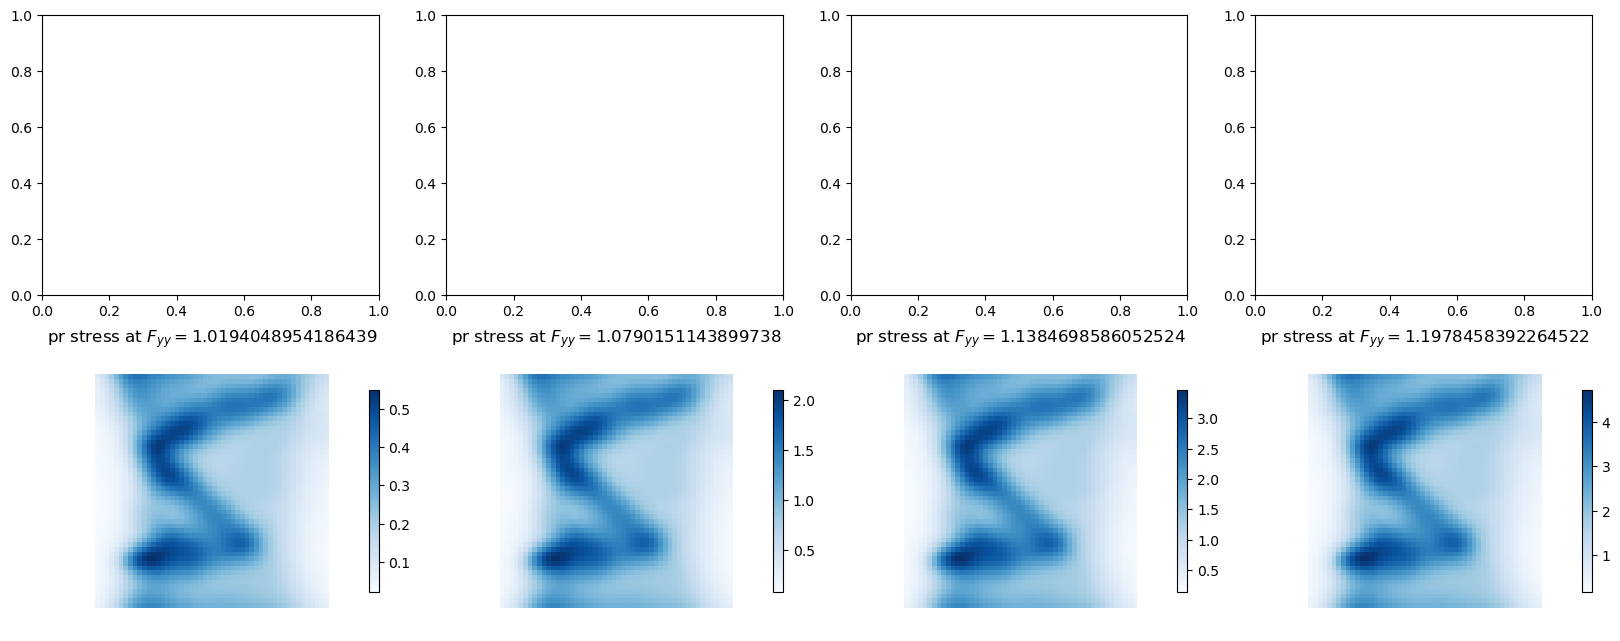

In [29]:
# Stiffness across the domain
fig, axes = plt.subplots(2,4,figsize=(20,8))
lmb_hist = [1.01929, 1.02728, 1.03531, 1.0433 , 1.05132]

extents = [[0.018, 0.021],
           [0.07, 0.08],
           [0.115, 0.13],
           [0.155, 0.17]]
for F_xx, F_yy, F_xy, F_yx, ax, extent in zip(F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean, axes.T, extents):
    # # ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])
    # lmbx = 1.0/lmb
    # ugrad = jnp.array([[lmbx-1.0, 0.0], [0.0, lmb-1.0]])

    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)

    # params_gt = []
    # for xy in elem_X:
    #     params_gt.append(coords_2_params_gt(xy))
    # params_gt = np.array(params_gt)
    params_pr = ff_nn(elem_X, Lambda_params)

    # c_elem_gt = []
    c_elem_pr = []
    # for params_gt_i, params_pr_i in zip(params_gt, params_pr):
    for params_pr_i in params_pr:
        # c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[1,1])

    # plotmesh(mesh.cells, mesh.points, c_elem_gt, title='gt stress at {}'.format(str(lmb)), ax=ax[0]); 
    # extent = [np.min(c_elem_gt), np.max(c_elem_gt)]

    # if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
    #     extend='both'
    # elif extent[0] > np.min(c_elem_pr):
    #     extend='min'
    # elif extent[1] < np.max(c_elem_pr):
    #     extend='max'
    plotmesh(mesh2.cells, mesh2.points, c_elem_pr, title='pr stress at $F_{yy}=$' + str(F_yy), ax=ax[1], ec='None'); 

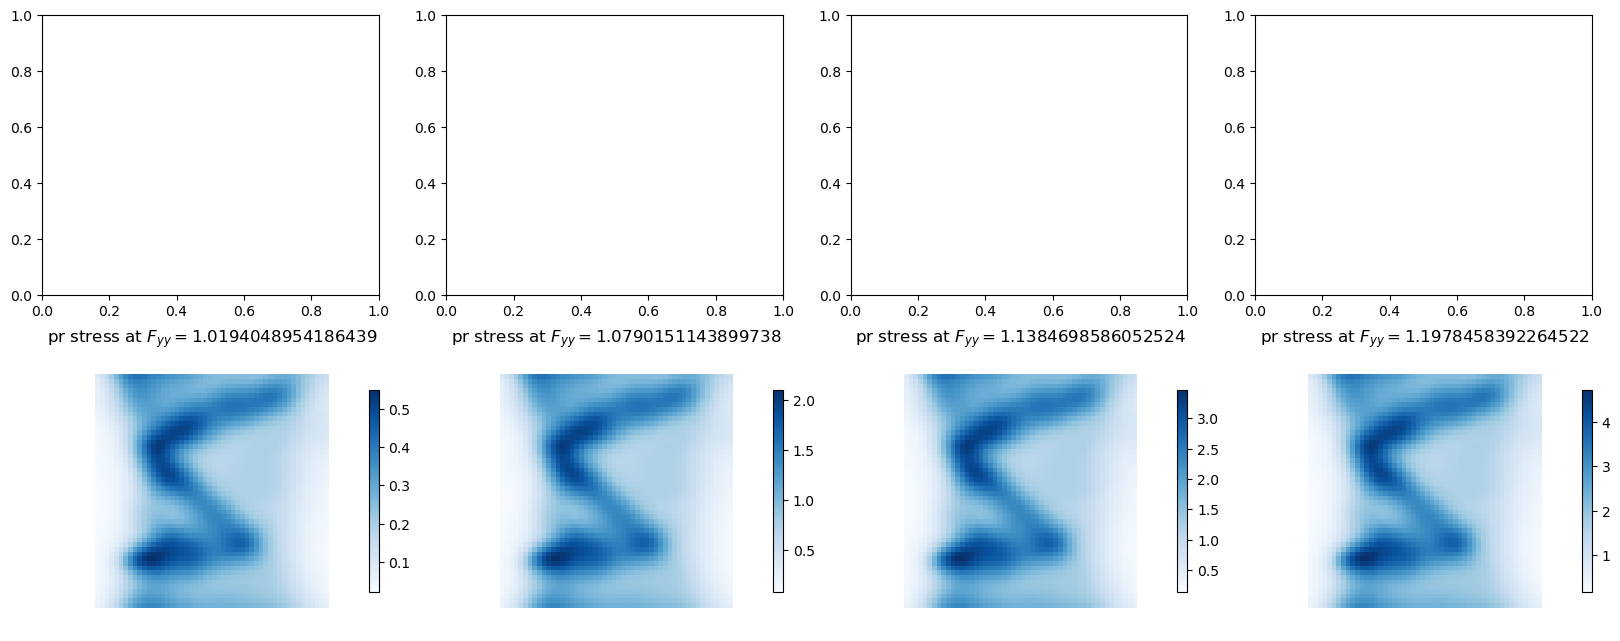

In [30]:
# Stiffness across the domain
fig, axes = plt.subplots(2,4,figsize=(20,8))
lmb_hist = [1.01929, 1.02728, 1.03531, 1.0433 , 1.05132]

extents = [[0.018, 0.021],
           [0.07, 0.08],
           [0.115, 0.13],
           [0.155, 0.17]]
for F_xx, F_yy, F_xy, F_yx, ax, extent in zip(F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean, axes.T, extents):
    # # ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])
    # lmbx = 1.0/lmb
    # ugrad = jnp.array([[lmbx-1.0, 0.0], [0.0, lmb-1.0]])

    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)

    # params_gt = []
    # for xy in elem_X:
    #     params_gt.append(coords_2_params_gt(xy))
    # params_gt = np.array(params_gt)
    params_pr = ff_nn(elem_X, Lambda_params)

    # c_elem_gt = []
    c_elem_pr = []
    # for params_gt_i, params_pr_i in zip(params_gt, params_pr):
    for params_pr_i in params_pr:
        # c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[1,1])

    # plotmesh(mesh.cells, mesh.points, c_elem_gt, title='gt stress at {}'.format(str(lmb)), ax=ax[0]); 
    # extent = [np.min(c_elem_gt), np.max(c_elem_gt)]

    # if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
    #     extend='both'
    # elif extent[0] > np.min(c_elem_pr):
    #     extend='min'
    # elif extent[1] < np.max(c_elem_pr):
    #     extend='max'
    plotmesh(mesh2.cells, mesh2.points, c_elem_pr, title='pr stress at $F_{yy}=$' + str(F_yy), ax=ax[1], ec='None'); 

In [4]:
P_vmap = vmap(ThreeDElasticity(NODE_w_unravel).ugrad_2_P, in_axes=(0, 0, None))
class HyperElasticity(FEM):
    def get_tensor_map(self):
        return lambda u_grad, params: ThreeDElasticity(NODE_w_unravel).ugrad_2_P(u_grad, params, self.dim)
    
    def set_params(self, params_vec):
        self.internal_vars['laplace'] = [params_vec]

In [5]:
params_vec = []
for x, y in elem_X:
    Lambda_inp = np.array([x,y]).reshape([-1,2])
    phi = ff_nn(Lambda_inp, Lambda_params).flatten()
    params_vec.append(phi)
params_vec = jnp.array(params_vec).reshape([len(params_vec),1,-1])
params_vec = jnp.repeat(params_vec, axis=1, repeats=4)

In [6]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)

Nx, Ny = 19, 19
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])


# Functions to identify the boundary nodes
def bottom(point):
    return jnp.isclose(point[1], 0., atol=1e-5)
def left(point):
    return jnp.isclose(point[0], 0., atol=1e-5)
def top(point):
    return jnp.isclose(point[1], Ly, atol=1e-5)
def right(point):
    return jnp.isclose(point[0], Lx, atol=1e-5)
def bottom_left(point):
    return jnp.logical_and(jnp.logical_and(bottom(point), left(point)), jnp.isclose(point[2], 0., atol=1e-5))


# Functions to assign dirichlet BCs
def zero_dirichlet(point):
    return 0.
def lmbx_max_dirichlet(point, lmbx_max):
    return Lx*lmbx_max - 1.0
def lmby_max_dirichlet(point, lmby_max):
    return Ly*lmby_max - 1.0


lmb_hist = [1.05, 1.10, 1.15, 1.20]
n_elem = Nx*Ny
C10 = jnp.zeros(n_elem)
k1  = jnp.zeros(n_elem)
k2  = jnp.zeros(n_elem)
F_hist = []
node_x_hist = []
P_hist = []
for lmb_max in lmb_hist:
    dirichlet_bc_info = [
        [bottom,            left,           top,                                        right,                                  ],
        [1,                 0,              1,                                          0,                                      ],
        [zero_dirichlet,    zero_dirichlet, lambda p: lmby_max_dirichlet(p, lmb_max),   lambda p: lmbx_max_dirichlet(p, lmb_max)]
    ]
    problem = HyperElasticity(mesh,
                            vec=2,
                            dim=2,
                            ele_type=ele_type,
                            dirichlet_bc_info=dirichlet_bc_info)
    elem_X = problem.get_physical_quad_points().mean(1)

    problem.set_params(params_vec)


    node_x = solver(problem, use_petsc=True)
    u_grad = np.mean(problem.sol_to_grad(node_x), axis=1)
    F = u_grad + np.eye(2)
    P = P_vmap(u_grad, params_vec[:,0,:], 2)
    
    F_hist.append(F)
    node_x_hist.append(node_x)
    P_hist.append(P)
node_x_hist = np.array(node_x_hist)
F_hist = np.array(F_hist)
P_hist = np.array(P_hist)

[01-29 12:02:18][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[01-29 12:02:18][DEBUG] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)
[01-29 12:02:18][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)
[01-29 12:02:19][DEBUG] jax_fem: Done pre-computations, took 0.3462047576904297 [s]
[01-29 12:02:19][INFO] jax_fem: Solving a problem with 361 cells, 400x2 = 800 dofs.
[01-29 12:02:19][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[01-29 12:02:19][DEBUG] jax_fem: Start timing
[01-29 12:02:19][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[01-29 12:02:22][DEBUG] jax_fem: Function split_and_compute_cell took 2.7130 seconds
[01-29 12:02:22][DEBUG] jax_fem: Creating sparse matrix with scipy...
[01-29 12:02:22][DEBUG] jax_fem: Linear guess solve...
[01-29 12:02:22][DEBUG] jax_fem: PETSc - Solving with ksp_type = bcgsl, pc = ilu
[01-29 12:02:22][DEBUG] jax_fem: PETSc 

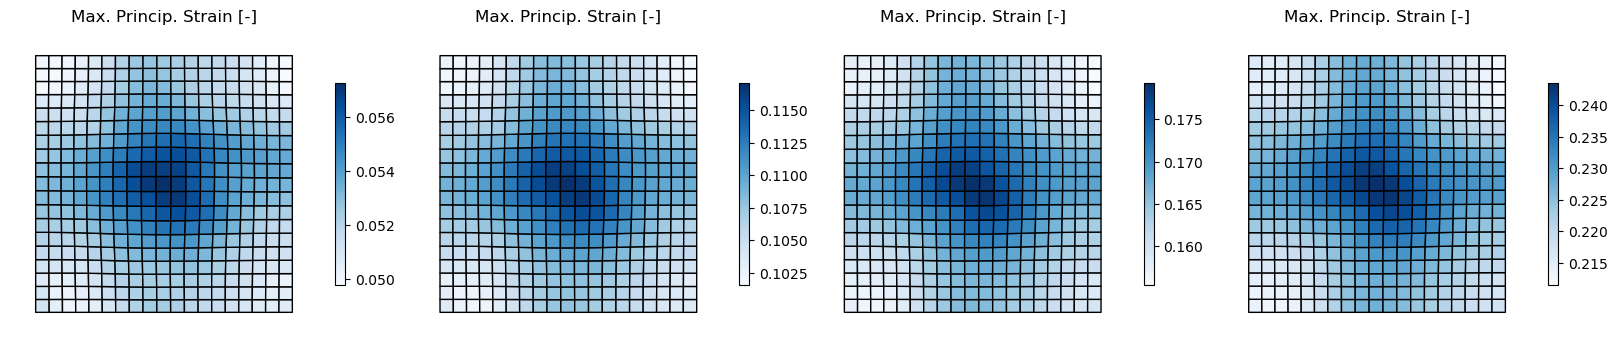

In [8]:
fig, axes = plt.subplots(1,4,figsize=(20,4))
strains = []
t_hist = np.arange(len(lmb_hist))
for t, node_x, F, ax in zip(t_hist, node_x_hist, F_hist, axes):
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T

    mps = np.maximum(E_11, E_22)
    plotmesh(mesh.cells, mesh.points, mps, title='Max. Princip. Strain [-]', ax=ax); 